In [1]:
# 使用 Huggingface transformers 加载
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoConfig, TrainingArguments, Trainer

model_path = 'G:/model_weights/models/model/mengzi-t5-base'
tokenizer = T5Tokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)
config = AutoConfig.from_pretrained(model_path)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [2]:
from datasets import load_dataset
dataset = load_dataset('json', data_files={'train': 'data/train.json', 'test': 'data/dev.json'})

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['context', 'answer', 'question', 'id'],
        num_rows: 14520
    })
    test: Dataset({
        features: ['context', 'answer', 'question', 'id'],
        num_rows: 984
    })
})

In [4]:
def tokenize(batch, tokenizer=tokenizer):
    # print(type(batch))
    # print(batch)
    # print(type(batch["context"]))

    inputs = '前文：' + batch["context"] + '问题:'  + batch["question"]
    targets = batch["answer"]
    # print(inputs)

    input_tensor = tokenizer(inputs,
                                    truncation=True,
                                    padding="max_length",
                                    max_length=512,
                                    # return_tensors="pt",
                                    )

    target_tensor = tokenizer(targets,
                                    truncation=True,
                                    padding="max_length",
                                    max_length=512,
                                    # return_tensors="pt",
                                    )

    input_tensor["labels"] = target_tensor["input_ids"]

    if "token_type_ids" in input_tensor:
        del input_tensor["token_type_ids"]
    input_tensor['input_ids'] = input_tensor['input_ids']
    input_tensor['attention_mask'] = input_tensor['attention_mask']
    return input_tensor

In [5]:
datasets = dataset.map(tokenize, num_proc=10,remove_columns=dataset["train"].column_names)

In [6]:
datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14520
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 984
    })
})

In [7]:
dataset['train'][0]

{'context': '第35集雪见缓缓张开眼睛，景天又惊又喜之际，长卿和紫萱的仙船驶至，见众人无恙，也十分高兴。众人登船，用尽合力把自身的真气和水分输给她。雪见终于醒过来了，但却一脸木然，全无反应。众人向常胤求助，却发现人世界竟没有雪见的身世纪录。长卿询问清微的身世，清微语带双关说一切上了天界便有答案。长卿驾驶仙船，众人决定立马动身，往天界而去。众人来到一荒山，长卿指出，魔界和天界相连。由魔界进入通过神魔之井，便可登天。众人至魔界入口，仿若一黑色的蝙蝠洞，但始终无法进入。后来花楹发现只要有翅膀便能飞入。于是景天等人打下许多乌鸦，模仿重楼的翅膀，制作数对翅膀状巨物。刚佩戴在身，便被吸入洞口。众人摔落在地，抬头发现魔界守卫。景天和众魔套交情，自称和魔尊重楼相熟，众魔不理，打了起来。',
 'answer': '第35集',
 'question': '仙剑奇侠传3第几集上天界',
 'id': 0}

In [ ]:
dataset_train = datasets['train'].select(range(13000))
dataset_dev = datasets['train'].select(range(13000, len(dataset['train'])))

In [21]:
output_dir = "G:/model_weights/fine_turning_model/t5" # 模型checkpoint的保存目录
training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=4, # batch_size需要根据自己GPU的显存进行设置，2080,8G显存，batch_size设置为2可以跑起来。
        logging_steps=10,
        #fp16=True,
        eval_strategy="steps",
        eval_steps=500,
        load_best_model_at_end=True,
        learning_rate=1e-5,
        #warmup_steps=100,
        output_dir=output_dir,
        save_total_limit=5,
        lr_scheduler_type='constant',
        gradient_accumulation_steps=1,
        dataloader_num_workers=0)

In [19]:
dataset_train

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 13000
})

In [22]:
print('Training Arguments ...')
print(training_args)

# trainer = Trainer(
#     tokenizer=tokenizer,
#     model=model,
#     args=training_args,
#     data_collator=collator,
#     train_dataset=train_sets,
#     eval_dataset=dev_sets
# )

trainer = Trainer(
    processing_class=tokenizer,
    model=model,
    args=training_args,
    # data_collator=tokenize,
    train_dataset=dataset_train,
    eval_dataset=dataset_dev
)

trainer.train()
trainer.save_model("G:/model_weights/fine_turning_model/t5/best") # 保存最好的模型

Training Arguments ...
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=500,
eval_strategy=IntervalStrategy.STEPS,
eval_us

Step,Training Loss,Validation Loss
500,0.008900,0.007511
1000,0.007800,0.006454
1500,0.004900,0.006062
2000,0.007300,0.005452
2500,0.006900,0.005222
3000,0.006400,0.004938
3500,0.004700,0.005261
4000,0.002400,0.004955
4500,0.003900,0.004793
5000,0.002000,0.004698


KeyboardInterrupt: 

# 模型训练收敛曲线

In [31]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [32]:
log_path = 'G:/model_weights/fine_turning_model/t5/checkpoint-7000/trainer_state.json'

with open(log_path, 'r', encoding='utf-8') as f:
    log = json.load(f)

loss_log = log["log_history"]
df_loss = pd.DataFrame(loss_log)
df_loss = df_loss.dropna(subset=["loss"])
df_loss.head()

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.003077,0.457459,0.00001,0.0043,10,NaN,NaN,NaN,NaN
1,0.006154,0.173016,0.00001,0.0055,20,NaN,NaN,NaN,NaN
2,0.009231,0.167967,0.00001,0.0038,30,NaN,NaN,NaN,NaN
3,0.012308,0.237235,0.00001,0.0055,40,NaN,NaN,NaN,NaN
4,0.015385,0.122683,0.00001,0.0060,50,NaN,NaN,NaN,NaN


In [33]:
df_loss = df_loss[df_loss["loss"] < 0.02]
loss = df_loss["loss"].values

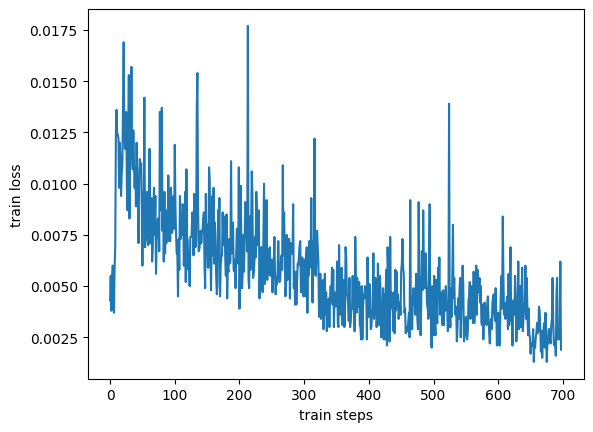

In [34]:
plt.plot(loss)
plt.xlabel('train steps')
plt.ylabel('train loss')
plt.show()

# 模型推断

In [10]:
from tqdm import tqdm
import torch
# 加载最优模型
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_model = "G:/model_weights/fine_turning_model/t5/checkpoint-7000/"
best_model = 'G:/model_weights/models/model/mengzi-t5-base'
tokenizer = T5Tokenizer.from_pretrained(best_model)
model = T5ForConditionalGeneration.from_pretrained(best_model).to(device)
model.eval()



T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [11]:
outputs = model.generate(tokenizer("前文：近十年来，中国高铁运营里程持续增长。截至2022年底，全国高铁运营里程已达4.2万公里，位居世界第一。其中，设计时速350公里的线路约占三分之一，主要分布在东部沿海和中部核心城市群。。 问题:中国高铁2022年底的运营里程是多少？", return_tensors="pt")["input_ids"].to(device))
outputs

tensor([[    0, 32127,     1]], device='cuda:0')

In [13]:
tokenizer.batch_decode(outputs, skip_special_tokens=True)

['']

In [14]:
def predict(source, batch_size=4):

    # kwargs = {"num_bases": 4}
    outputs = []
    for start in tqdm(range(0, len(source), batch_size)):
        inputs = source[start: min(start+batch_size, len(source))]['input_ids']
        inputs = torch.tensor(inputs).to(device)

        output = model.generate(inputs)
        outputs.extend(output)
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)


In [15]:
datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14520
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 984
    })
})

In [16]:
res = predict(datasets["test"])

100%|██████████| 246/246 [00:27<00:00,  9.03it/s]


In [17]:
idx = 8
dataset["test"][idx]

{'context': '密歇根州。地理位置：密歇根州（Michigan）位于美国最北部，由两大半岛组成，分隔两半岛的水面叫做麦基诺水道。南为下半岛，是该州的主体，面积较大，其南境西半部接印第安纳州，东半部接俄亥俄州。半岛西、北、东三方面均为湖泊，西、北为密歇根湖，东北为休伦湖，东为圣克莱尔湖与圣克莱尔河，东南是伊利湖。北部为上半岛，面积比下半岛小，北滨苏必利尔湖，南临密歇根湖，西南邻威斯康星州，东端为圣马里斯河及苏运河。气候与面积：州面积250,493平方公里，居美国50州第11位。位于五大湖区，受湖风调剂，气候温和。北方的苏圣玛丽城平均最高温度为10℃，平均最低温度为-1℃。东南部的底特律市平均最高温度为14℃，平均最低温度为6℃。上半岛的生长期约为3个月，而下半岛的南部地区长达6个月。年平均降水量838毫米，南部较多，达914毫米。城市与人口：人口987.6万（2011年），居全美第8位，白人占总人口的79.6%，黑人占14%。密州有83个郡，州府兰辛市（Lansing），人口11.6万，为州政治、文化及教育中心。底特律（Detroit）是密州最大城市，人口87万。大底特律地区华侨华人较为集中。历史：17世纪时为印第安人居住地，1668年法国殖民者建立第一个定居点，1701年底特律成为皮毛贸易中心，1783年以后归属美国。1837年加入联邦，成为美国第26个州。',
 'answer': '密歇根州',
 'question': 'mi是美国哪个州的缩写',
 'id': 8}

In [18]:
res[idx]

'边边边边边边边边边边边边边边边边边边边'

# 模型测评

In [19]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import jieba  # 用于中文分词

# 中文分词函数
def tokenize_chinese(text):
    return list(jieba.cut(text))

# 模型生成结果（hypotheses）
hypotheses = res

# 参考答案（每个 hypothesis 对应一个 reference 列表）
references = dataset["test"][:]['answer']

# 分词
tokenized_hyps = [tokenize_chinese(hyp) for hyp in hypotheses]
tokenized_refs = [[tokenize_chinese(ref) for ref in ref_list] for ref_list in references]

# 平滑函数（避免零分）
smooth = SmoothingFunction().method4

# 计算每个样本的 BLEU-1 到 BLEU-4
bleu_scores = []
err_num = 0
for hyp, refs in zip(tokenized_hyps, tokenized_refs):
    try:
        bleu1 = sentence_bleu(refs, hyp, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(refs, hyp, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(refs, hyp, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(refs, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    except:
        err_num += 1
    bleu_scores.append((bleu1, bleu2, bleu3, bleu4))

# # 打印每个样本的 BLEU 分数
# for i, (b1, b2, b3, b4) in enumerate(bleu_scores):
#     print(f"样本 {i+1}: BLEU-1={b1:.4f}, BLEU-2={b2:.4f}, BLEU-3={b3:.4f}, BLEU-4={b4:.4f}")

# 计算平均 BLEU 分数（可选）
avg_bleu1 = sum(s[0] for s in bleu_scores) / len(bleu_scores)
avg_bleu2 = sum(s[1] for s in bleu_scores) / len(bleu_scores)
avg_bleu3 = sum(s[2] for s in bleu_scores) / len(bleu_scores)
avg_bleu4 = sum(s[3] for s in bleu_scores) / len(bleu_scores)
print(f"处理出错的样本数: {err_num}")

print("\n平均 BLEU 分数:")
print(f"BLEU-1: {avg_bleu1:.4f}")
print(f"BLEU-2: {avg_bleu2:.4f}")
print(f"BLEU-3: {avg_bleu3:.4f}")
print(f"BLEU-4: {avg_bleu4:.4f}")

g:\software\anaconda\envs\pytorch\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lkjx0\AppData\Local\Temp\jieba.cache
Loading model cost 0.290 seconds.
Prefix dict has been built successfully.


处理出错的样本数: 1

平均 BLEU 分数:
BLEU-1: 0.0006
BLEU-2: 0.0003
BLEU-3: 0.0002
BLEU-4: 0.0001
